# Module 8 — Methane Oxidation and NOx-Driven Ozone Production
### B4 Chemistry in the Atmosphere · companion notebook

Covers: Example 3 (photostationary-state timescale), the Leighton relationship, the
low-/high-NOx ozone production transition, and a simple ozone isopleth.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['font.size'] = 11

## Example 3 — photostationary state establishment timescale

$$\tau_{PSS} \approx (J_{3.10} + k_{3.12}[O_3])^{-1}$$

In [2]:
J_3_10 = 1.0e-2      # s^-1, typical midday NO2 photolysis rate (see Module 3, Fig 3.10)
k_3_12 = 2e-12 * np.exp(-1400/298)   # cm^3 molecule^-1 s^-1 at 298 K
O3_ppb = 40
M = 2.5e19
O3_conc = O3_ppb*1e-9*M

tau_pss = 1/(J_3_10 + k_3_12*O3_conc)
print(f"k_3.12 at 298K = {k_3_12:.3e} cm^3 s^-1")
print(f"tau_PSS = {tau_pss:.1f} s")

k_3.12 at 298K = 1.823e-14 cm^3 s^-1
tau_PSS = 35.4 s


## Leighton relationship

$$[O_3]_{ss} = \frac{J_{3.10}[NO_2]}{k_{3.12}[NO]}$$

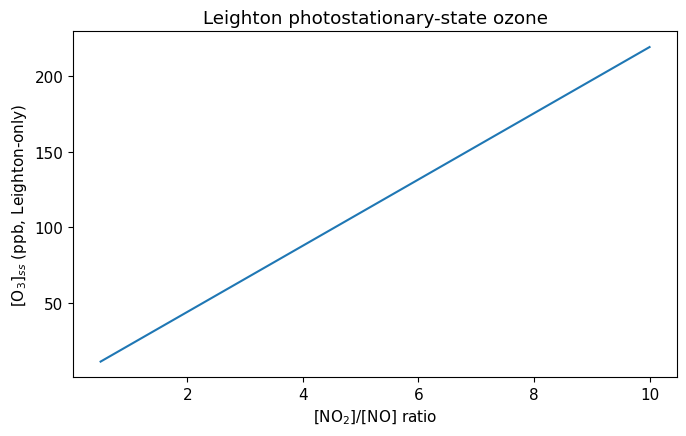

In [3]:
def O3_leighton(NO2_ppb, NO_ppb, J=J_3_10, k=k_3_12, M=M):
    NO2 = NO2_ppb*1e-9*M
    NO = NO_ppb*1e-9*M
    return J*NO2 / (k*NO) / M * 1e9   # back to ppb

NO2_NO_ratios = np.linspace(0.5, 10, 40)
O3_vals = [O3_leighton(NO2_ppb=r, NO_ppb=1) for r in NO2_NO_ratios]

plt.figure()
plt.plot(NO2_NO_ratios, O3_vals)
plt.xlabel('[NO$_2$]/[NO] ratio')
plt.ylabel('[O$_3$]$_{ss}$ (ppb, Leighton-only)')
plt.title('Leighton photostationary-state ozone')
plt.tight_layout()
plt.show()

## Low-/high-NOx transition (Sec 3.5)

Transition [NO] where NO+HO2 (k3.13) starts to compete with O3+HO2 (k3.8):

$$[NO]_{transition} = \frac{k_{3.8}[O_3]}{k_{3.13}}$$

In [4]:
k_3_13 = 8e-12
k_3_8 = 2e-15

def NO_transition(O3_ppb, M=M):
    O3_conc = O3_ppb*1e-9*M
    NO_conc = k_3_8*O3_conc/k_3_13
    return NO_conc/M*1e9  # ppb -> pptv further down

NO_trans_ppb = NO_transition(40)
print(f"Transition [NO] at 40 ppb O3: {NO_trans_ppb*1000:.2f} pptv (notes: ~10 pptv)")

Transition [NO] at 40 ppb O3: 10.00 pptv (notes: ~10 pptv)


## Qualitative net O3 production vs [NO]

We build a toy net-production curve: net = P(O3) - L(O3), where P(O3) ~ k3.13[HO2][NO]
(saturating/turning over at high NO due to R3.16 termination) and L(O3) ~ k3.8[HO2][O3]
(NOx-independent).

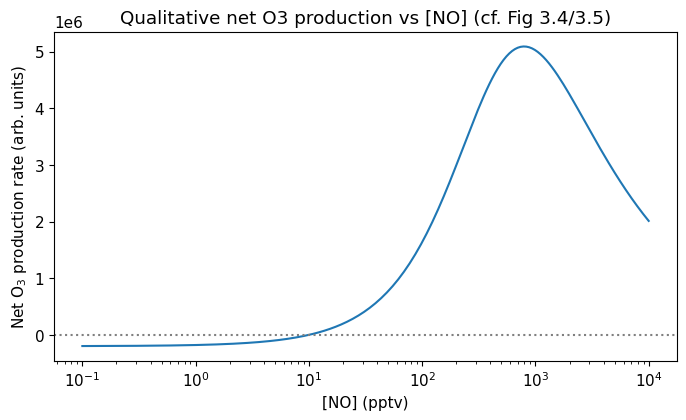

Net production crosses zero near [NO] ~ 9.66 pptv


In [5]:
def net_O3_production(NO_ppt, HO2=1e8, O3_ppb=40, M=M,
                       k_termination_onset_ppt=500):
    NO_conc = NO_ppt*1e-12*M
    O3_conc = O3_ppb*1e-9*M

    P = k_3_13 * HO2 * NO_conc
    # Empirical turnover: production efficiency falls off above k_termination_onset_ppt
    # (representing increasing OH+NO2 -> HNO3 termination, R3.16, at high NOx)
    turnover = 1 / (1 + (NO_ppt/k_termination_onset_ppt)**1.5)
    P_eff = P * turnover

    L = k_3_8 * HO2 * O3_conc
    return P_eff - L

NO_ppt_range = np.logspace(-1, 4, 200)
net = [net_O3_production(n) for n in NO_ppt_range]

plt.figure()
plt.semilogx(NO_ppt_range, net)
plt.axhline(0, color='gray', ls=':')
plt.xlabel('[NO] (pptv)')
plt.ylabel('Net O$_3$ production rate (arb. units)')
plt.title('Qualitative net O3 production vs [NO] (cf. Fig 3.4/3.5)')
plt.tight_layout()
plt.show()

# Find where net production crosses zero
zero_crossing_idx = np.where(np.diff(np.sign(net)))[0]
if len(zero_crossing_idx) > 0:
    print(f"Net production crosses zero near [NO] ~ {NO_ppt_range[zero_crossing_idx[0]]:.2f} pptv")

## A toy ozone isopleth

A crude functional form capturing NOx-limited vs. VOC-limited regimes: at low NOx, adding NOx
increases O3 (NOx-limited); at high NOx, adding VOC increases O3 but adding more NOx can reduce
it (VOC-limited), because of increasing HNO3 termination.

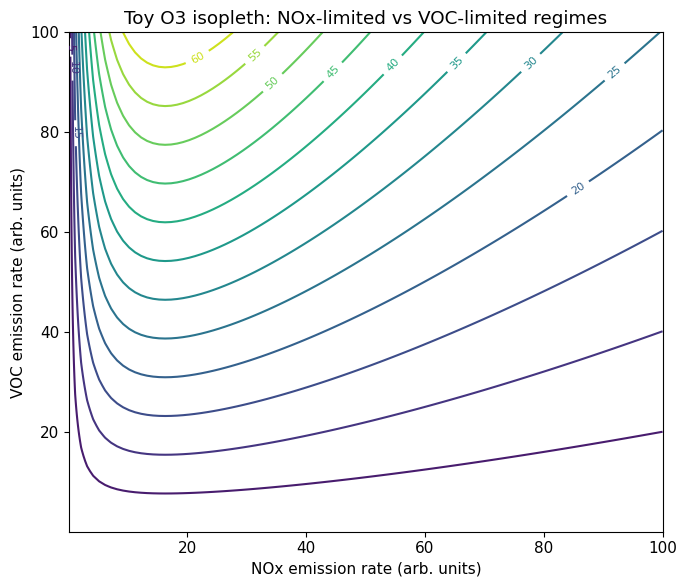

Bottom-right of the plot (high NOx, low-moderate VOC): VOC-limited.
Top-left (low NOx, high VOC): NOx-limited.


In [6]:
def ozone_isopleth(NOx, VOC):
    # crude combination: O3 grows with VOC oxidation rate (~ proportional to VOC and to
    # NO2 conversion efficiency, which itself saturates and then falls with NOx)
    conversion_efficiency = NOx / (NOx + 5) * (1 / (1 + (NOx/50)**1.5))
    return VOC * conversion_efficiency

NOx_range = np.linspace(0.1, 100, 100)
VOC_range = np.linspace(0.1, 100, 100)
NOx_grid, VOC_grid = np.meshgrid(NOx_range, VOC_range)
O3_grid = ozone_isopleth(NOx_grid, VOC_grid)

plt.figure(figsize=(7,6))
cs = plt.contour(NOx_grid, VOC_grid, O3_grid, levels=12)
plt.clabel(cs, inline=True, fontsize=8)
plt.xlabel('NOx emission rate (arb. units)')
plt.ylabel('VOC emission rate (arb. units)')
plt.title('Toy O3 isopleth: NOx-limited vs VOC-limited regimes')
plt.tight_layout()
plt.show()

print("Bottom-right of the plot (high NOx, low-moderate VOC): VOC-limited.")
print("Top-left (low NOx, high VOC): NOx-limited.")

## Exercises

1. **PSS timescale vs time of day.** Using a diurnal J(3.10) profile (e.g. a sine-wave switching
   off at night, as in Module 2's exercises), plot how tau_PSS varies over 24 hours. When is the
   photostationary-state approximation most/least valid?

2. **Transition [NO] vs altitude.** [O3] and temperature (via k3.8, k3.13's weak T-dependence)
   both change with altitude. Using representative boundary-layer vs. upper-tropospheric [O3],
   how much does the low-/high-NOx transition concentration shift?

3. **Isopleth realism.** The toy isopleth above is illustrative, not fitted to real chemistry.
   Adjust its functional form so that a fixed increase in NOx at low NOx always increases O3
   (NOx-limited regime) while the same increase at high NOx can decrease O3 (VOC-limited regime)
   -- confirm your adjusted isopleth reproduces both point A and point C behaviour described in
   the notes.